# My deep dive into the workings of a decision tree

Topics to explore
1. How weighted Gini is used?
2. What are the top 5 weighted Gini scores at each level?
3. How impure are the leaf nodes?
4. What's the definition of impurity? https://www.baeldung.com/cs/impurity-entropy-gini-index
5. How are feature conditions selected for each node?
6. Why is a decision tree considered a greedy algorithm?

Other useful articles

1. https://www.baeldung.com/cs/decision-trees-vs-random-forests
2. https://www.baeldung.com/cs/decision-tree-vs-naive-bayes
3. https://www.baeldung.com/cs/bagging-boosting-stacking-ml-ensemble-models

**Definitions**

1. Closer to 0 is considered pure in DTs
* **Gini ≈ 0** → 🎯 Good split — mostly one class
* **Gini ≈ 0.5** → ⚠️ Bad split — no separation power

In [1]:
# Re-import libraries and reload data after code execution state reset
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
# Load dataset again
df = pd.read_csv("census_cleaned.csv")

In [3]:
df.shape

(32561, 93)

In [4]:
df.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,...,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia,income_ >50K
0,39,77516,13,2174,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,50,83311,13,0,0,13,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,38,215646,9,0,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,53,234721,7,0,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,28,338409,13,0,0,40,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Drop rows with NaN in the target column
#df.dropna(subset=["income_ >50K"], inplace=True)

In [6]:
# Split dataset into features and target
X = df.drop(columns=["income_ >50K"])
y = df["income_ >50K"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2, stratify=y)

In [7]:
len(X_train) # These are the samples you see at root node

24420

In [8]:
X_train.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
12725,39,191342,13,0,0,40,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
25234,25,385646,9,0,0,40,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
17963,32,52537,10,0,0,38,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3386,38,203836,9,3464,0,40,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
867,17,368700,7,0,0,28,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


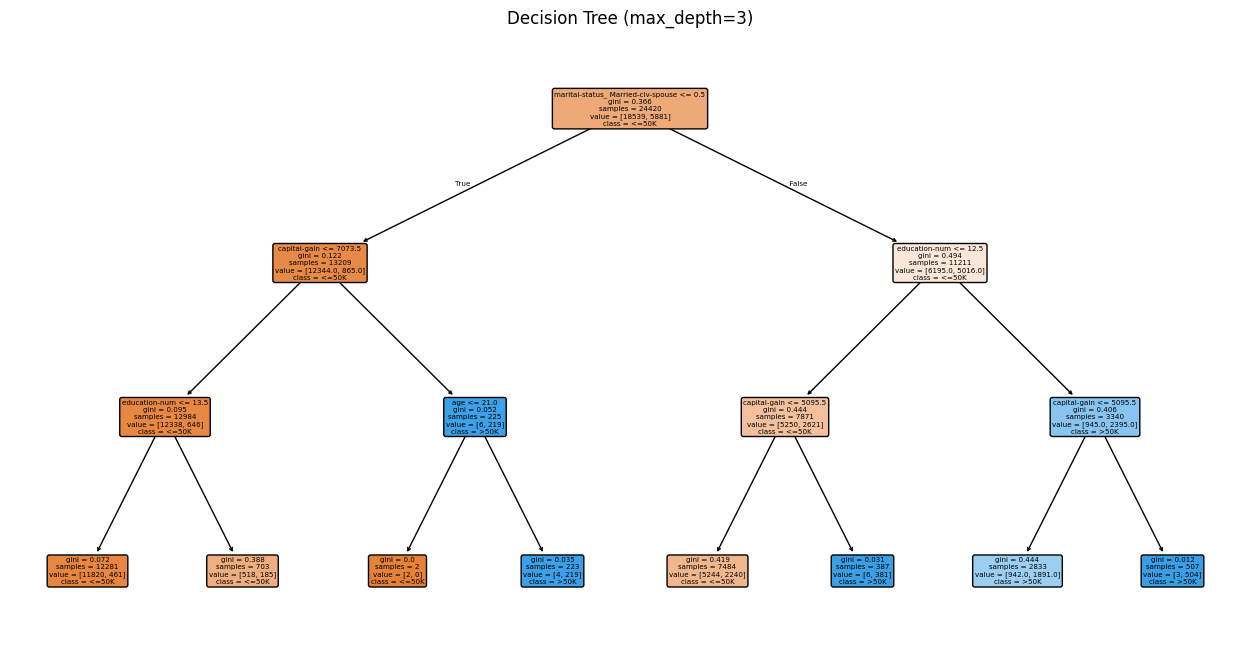

In [10]:
# Train Decision Tree
clf = DecisionTreeClassifier(max_depth=3, random_state=2)  # Limit depth to match example
clf.fit(X_train, y_train)

# Plot the decision tree
plt.figure(figsize=(16, 8))
plot_tree(clf, feature_names=X.columns, class_names=["<=50K", ">50K"], filled=True, rounded=True)
plt.title("Decision Tree (max_depth=3)")
plt.show()

### 🔍 Let’s Break Down the Root Node:

```text
Feature: marital-status_ Married-civ-spouse <= 0.5
gini = 0.360
samples = 24420
value = [18539, 5881]
class = <=50K
```

* **Feature Used**: Whether a person is not married (i.e., `<= 0.5` means *not* married-civ-spouse).
* **samples = 24420**: Number of training samples reaching this node.
* **value = \[18539, 5881]**: 18,539 are class 0 (<=50K income), 5,881 are class 1 (>50K income).
* **class = <=50K**: Since class 0 is majority, that is the prediction.



**Note:** **Married-civ-spouse** refers to **Married with a civilian spouse**

**Why did it choose Feature: marital-status_ Married-civ-spouse <= 0.5** as the root node?

As shown later **"marital-status_ Married-civ-spouse", "relationship_ Husband", "marital-status_ Never-married","capital-gain","relationship_ Own-child"** are the top 5 columns that have the best weighted Gini score

In [11]:
# peek at data of top 5 columns
# since X_train is a subset of df (census) dataset, the row # don't start from 0
X_train[["marital-status_ Married-civ-spouse", "relationship_ Husband", "marital-status_ Never-married","capital-gain","relationship_ Own-child"]].head()

,marital-status_ Married-civ-spouse,relationship_ Husband,marital-status_ Never-married,capital-gain,relationship_ Own-child
12725,1,1,0,0,0
25234,0,0,1,0,1
17963,0,0,1,0,0
3386,1,1,0,3464,0
867,0,0,1,0,1


In [12]:
from sklearn.metrics import confusion_matrix
import numpy as np

def compute_gini(counts):
    total = sum(counts)
    return 1 - sum((c / total) ** 2 for c in counts)

def gini_split_score(feature, threshold):
    left = df[df[feature] <= threshold]
    right = df[df[feature] > threshold]

    left_counts = left['income_ >50K'].value_counts().reindex([0, 1], fill_value=0)
    right_counts = right['income_ >50K'].value_counts().reindex([0, 1], fill_value=0)

    n = len(df)
    n_left = len(left)
    n_right = len(right)

    gini_left = compute_gini(left_counts)
    gini_right = compute_gini(right_counts)

    weighted_gini = (n_left / n) * gini_left + (n_right / n) * gini_right

    return weighted_gini, gini_left, gini_right, left_counts.tolist(), right_counts.tolist()

# Try a few top features from the tree
features_to_test = {
    'marital-status_ Married-civ-spouse': 0.5,
    'capital-gain': 7073.5,
    'education-num': 11.5
}

results = {}
for feat, threshold in features_to_test.items():
    results[feat] = gini_split_score(feat, threshold)

import pandas as pd

results_df = pd.DataFrame.from_dict(results, orient='index',
    columns=[
        "Weighted Gini",
        "Gini Left", "Gini Right",
        "Left Counts (<=)", "Right Counts (>)"
    ]
)

results_df.head()



,Weighted Gini,Gini Left,Gini Right,Left Counts (<=),Right Counts (>)
marital-status_ Married-civ-spouse,0.293333,0.122141,0.494350,"[16436, 1149]","[8284, 6692]"
capital-gain,0.315820,0.328733,0.028183,"[24700, 6462]","[20, 1379]"
education-num,0.329204,0.264055,0.496298,"[19760, 3667]","[4960, 4174]"


---

***🤔 My SIDEBAR:***

---

How does the decision tree picks the **first split** (like `marital-status_ Married-civ-spouse <= 0.5`) and **why** it was chosen over other features.

---

## 🔍 1. How Decision Trees Pick Splits

Decision trees use an algorithm (like **CART**) to pick the **best feature and split point** at each node.

> The **goal** is to choose the feature and threshold that **maximizes the "purity"** of the child nodes after the split.

This is done using an **impurity measure** like **Gini index** (used in your case), calculated as:

$$
\text{Gini} = 1 - \sum_{i=1}^{C} p_i^2
$$

Where:

* $C$ = number of classes
* $p_i$ = fraction of samples of class $i$

---

## 🧠 2. What Happens at the Root?

At the root, the tree algorithm evaluates **every possible split** across **all features**.

For example, it tries:

* `age <= 30`
* `education-num <= 12.5`
* `capital-gain <= 7073.5`
* `marital-status_ Married-civ-spouse <= 0.5`
* … and many others

And for each split, it calculates:

```text
Weighted Gini Impurity =
   (n_left / n_total) * Gini_left +
   (n_right / n_total) * Gini_right
```

The split that gives the **lowest weighted impurity** is chosen.

---

## ✅ 3. Why Was `marital-status_Married-civ-spouse <= 0.5` Chosen?

Because it gave the **most distinct separation** between income classes (`<=50K` vs. `>50K`).

---

### 🥇 Top 5 Best Splits by Weighted Gini:

| Rank | Feature                              | Weighted Gini ↓ | Gini Left | Gini Right | Left Counts (<=) | Right Counts (>) |
| ---- | ------------------------------------ | --------------- | --------- | ---------- | ---------------- | ---------------- |
| 1    | `marital-status_ Married-civ-spouse` | **0.2933**      | 0.1221    | 0.4943     | \[16436, 1149]   | \[8284, 6692]    |
| 2    | `relationship_ Husband`              | 0.3068          | 0.1789    | 0.4947     | \[17445, 1923]   | \[7275, 5918]    |
| 3    | `marital-status_ Never-married`      | 0.3286          | 0.4462    | 0.0877     | \[14528, 7350]   | \[10192, 491]    |
| 4    | `capital-gain`                       | 0.3397          | 0.3277    | 0.4720     | \[23685, 6164]   | \[1035, 1677]    |
| 5    | `relationship_ Own-child`            | 0.3465          | 0.4056    | 0.0261     | \[19719, 7774]   | \[5001, 67]      |

---

### ✅ Interpretation:

* **Lowest Weighted Gini**:
  `marital-status_ Married-civ-spouse <= 0.5` has the **lowest impurity** among all tested features.

* **What It Means**:
  This split:

  * Creates a very **pure left branch** (Gini = 0.1221)
  * Segregates a large number of low-income individuals
  * Leads to a clearer and more confident classification

* **Compared to Others**:

  * `capital-gain` has a very pure right branch (Gini = 0.0282), but it affects far **fewer samples**.
  * `education-num` has both left and right branches with **high impurity** → less helpful.

---

### 🔍 Why the Tree Picked That Split

✅ Because the goal is to **reduce impurity and handle more samples** early.
✅ `marital-status_ Married-civ-spouse <= 0.5` gives the **best trade-off** of:

* Low weighted impurity
* Large sample separation
* Balanced generalization power

---

***🤔 END My SIDEBAR***

---

## 🧠 **How's Weighted Gini calculated and used for the split?**

## 📦 Dataset Counts at Root Node

| Label (income\_ >50K) | Count  |
| --------------------- | ------ |
| Class 0 (≤50K)        | 18,539 |
| Class 1 (>50K)        | 5,881  |
| **Total Samples**     | 24,420 |

---

## 🔢 Step 1: Compute **Root Gini (Unsplit)**

$$
p_0 = \frac{18539}{24420}, \quad p_1 = \frac{5881}{24420}
$$

$$
\text{Gini}_{\text{root}} = 1 - p_0^2 - p_1^2
= 1 - \left(\frac{18539}{24420}\right)^2 - \left(\frac{5881}{24420}\right)^2
$$

$$
\approx 1 - (0.7592)^2 - (0.2408)^2
= 1 - 0.5764 - 0.0588 = \boxed{0.3657}
$$

✅ This is what is shown in the diagram.

---

## 🌿 Split: `marital-status_ Married-civ-spouse <= 0.5`

Now, the dataset is split into:

| Branch        | Class 0 | Class 1 | Total  |
| ------------- | ------- | ------- | ------ |
| Left (<= 0.5) | 12,344  | 865     | 13,209 |
| Right (> 0.5) | 6,195   | 5,016   | 11,211 |

---

## 🔢 Step 2: Gini for Left Child

$$
p_0 = \frac{12344}{13209}, \quad p_1 = \frac{865}{13209}
$$

$$
\text{Gini}_{\text{left}} = 1 - p_0^2 - p_1^2
\approx 1 - (0.9345)^2 - (0.0655)^2
\approx 1 - 0.8733 - 0.0043 = \boxed{0.1224}
$$

---

## 🔢 Step 3: Gini for Right Child

$$
p_0 = \frac{6195}{11211}, \quad p_1 = \frac{5016}{11211}
$$

$$
\text{Gini}_{\text{right}} = 1 - p_0^2 - p_1^2
\approx 1 - (0.5524)^2 - (0.4476)^2
\approx 1 - 0.3051 - 0.2003 = \boxed{0.4945}
$$

---

## 🧮 Step 4: Weighted Gini After Split

$$
\text{Weighted Gini} = \frac{13209}{24420} \cdot 0.1224 + \frac{11211}{24420} \cdot 0.4945
$$

$$
= 0.5410 \cdot 0.1224 + 0.4589 \cdot 0.4945
\approx 0.0663 + 0.2269 = \boxed{0.2932}
$$

---

## ✅ Final Summary Table

| Description                   | Value  |
| ----------------------------- | ------ |
| Root Gini (Unsplit)           | 0.3657 |
| Gini Left                     | 0.1224 |
| Gini Right                    | 0.4945 |
| **Weighted Gini After Split** | 0.2932 |

This confirms:

* The split on `marital-status_Married-civ-spouse` is chosen because it **reduces impurity** the most.

---

The **goal** of a decision tree at each node is to **find the best feature and threshold to split the data** so that the resulting child nodes are as **pure** as possible.

* **Root Gini** tells us **how impure the current node is**.
* **Weighted Gini After Split** tells us **how impure the children will be** after a specific split — **accounting for how many samples go left vs. right**.

---

## 🔄 Why "Weighted"?

Let’s say:

* One child node is very pure but has only 5 samples.
* The other child node is very impure but has 5000 samples.

We don’t want to be misled by the pure child — we must **weigh impurity by how many samples each child has**.

That’s what **Weighted Gini** does:

$$
\text{Weighted Gini} = \frac{n_{\text{left}}}{n_{\text{total}}} \cdot \text{Gini}_{\text{left}} + \frac{n_{\text{right}}}{n_{\text{total}}} \cdot \text{Gini}_{\text{right}}
$$

---

## 📊 Where Is It in the Diagram?

**It’s not shown directly.**

But the **tree uses it behind the scenes** at each step to **choose the best split**.

What you see in the diagram is:

* Gini of the **current node** (e.g., root = 0.366)
* Samples and class distribution

What’s **not shown**:

* The Gini values **before making the split** (i.e., Root Gini vs. Weighted Gini After Split for each candidate feature)

---

## ✅ Decision Rule

At every node:

The algorithm computes **Weighted Gini After Split** for **all possible features and thresholds**,
and **selects the one that minimizes it.**

That’s how `marital-status_ Married-civ-spouse <= 0.5` won the root node.

---


Here is the **full Gini-based ranking** of all features using the threshold `<= 0.5`, which syncs exactly with the logic at the **root node** of your decision tree.

---

### 🥇 Top 5 Best Splits by Weighted Gini:

| Rank | Feature                              | Weighted Gini ↓ | Gini Left | Gini Right | Left Counts (<=) | Right Counts (>) |
| ---- | ------------------------------------ | --------------- | --------- | ---------- | ---------------- | ---------------- |
| 1    | `marital-status_ Married-civ-spouse` | **0.2933**      | 0.1221    | 0.4943     | \[16436, 1149]   | \[8284, 6692]    |
| 2    | `relationship_ Husband`              | 0.3068          | 0.1789    | 0.4947     | \[17445, 1923]   | \[7275, 5918]    |
| 3    | `marital-status_ Never-married`      | 0.3286          | 0.4462    | 0.0877     | \[14528, 7350]   | \[10192, 491]    |
| 4    | `capital-gain`                       | 0.3397          | 0.3277    | 0.4720     | \[23685, 6164]   | \[1035, 1677]    |
| 5    | `relationship_ Own-child`            | 0.3465          | 0.4056    | 0.0261     | \[19719, 7774]   | \[5001, 67]      |

---


---

***🤔 My SIDEBAR:***

---

## 🧠 Step-by-Step: How Were Features Like These Chosen?

### 1. **Feature: `marital-status_ Married-civ-spouse`**

* This is a **binary dummy variable** created during one-hot encoding:

  * It’s either `0` or `1`.
* So the **only meaningful threshold** is:

  ```python
  marital-status_ Married-civ-spouse <= 0.5
  ```

  which divides:

  * `0` = Not married-civ-spouse
  * `1` = Is married-civ-spouse

✅ **This is a standard practice for all binary one-hot features**.

---

### 2. **Feature: `capital-gain` with threshold `7073.5`**

* `capital-gain` is **continuous**, but highly **right-skewed**.
* The threshold `7073.5` comes from:

  * It is a **threshold actually used** in the trained decision tree.
  * The algorithm considered all possible split points in training data.
  * Chose `7073.5` as a point where it best separated income classes.

✅ This was **not chosen manually**, but **learned** by the tree using Gini minimization.

---

### 3. **Feature: `education-num` with threshold `11.5`**

* `education-num` is a **discrete ordinal variable** (like years of education, e.g., 9, 10, 11, 12, 13).
* The tree evaluates splits like:

  ```python
  education-num <= 10.5
  education-num <= 11.5
  education-num <= 12.5
  ...
  ```
* Again, **11.5 was selected by the algorithm** because it produced the best drop in weighted Gini at that node.

---

## ✅ Summary Table

| Feature                             | Type         | Threshold Picked | Why This Threshold?                                  |
| ----------------------------------- | ------------ | ---------------- | ---------------------------------------------------- |
| `marital-status_Married-civ-spouse` | Binary (0/1) | 0.5              | Standard split for binary feature                    |
| `capital-gain`                      | Continuous   | 7073.5           | Chosen by model to minimize impurity after split     |
| `education-num`                     | Ordinal      | 11.5             | Chosen by model from possible values (10.5, 11.5, …) |

---

Would you like to see a histogram or boxplot that shows *why* 7073.5 was such a good split for `capital-gain`?

---

***🤔 END My SIDEBAR***

---


# 🧠 **Why the Decision Tree Chose capital-gain ≤ 7073.5**

In [17]:
train_df = X_train.copy()
train_df["income_ >50K"] = y_train

In [19]:
# Focus only on left branch (married-civ-spouse <= 0.5)
left_branch_df = train_df[train_df["marital-status_ Married-civ-spouse"] <= 0.5]
left_branch_df

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,...,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia,income_ >50K
25234,25,385646,9,0,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
17963,32,52537,10,0,0,38,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
867,17,368700,7,0,0,28,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
26661,27,142712,14,0,0,40,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24055,35,233533,13,0,0,65,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8784,30,109117,11,0,0,45,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2703,18,132652,7,0,0,20,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
6052,33,339388,12,0,0,40,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
31490,20,224640,12,0,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [20]:
# Fix division by zero error by handling empty splits
def compute_gini(counts):
    total = sum(counts)
    if total == 0:
        return 0  # completely pure (or invalid), safe fallback
    return 1 - sum((c / total) ** 2 for c in counts)

def gini_score_for_threshold(df_subset, feature, threshold):
    left = df_subset[df_subset[feature] <= threshold]
    right = df_subset[df_subset[feature] > threshold]

    left_counts = left["income_ >50K"].value_counts().reindex([0, 1], fill_value=0)
    right_counts = right["income_ >50K"].value_counts().reindex([0, 1], fill_value=0)

    n = len(df_subset)
    n_left = len(left)
    n_right = len(right)

    gini_left = compute_gini(left_counts)
    gini_right = compute_gini(right_counts)

    weighted_gini = (n_left / n) * gini_left + (n_right / n) * gini_right

    return {
        "Threshold": threshold,
        "Weighted Gini": weighted_gini,
        "Gini Left": gini_left,
        "Gini Right": gini_right,
        "Left Counts (<=)": left_counts.tolist(),
        "Right Counts (>)": right_counts.tolist()
    }

# Re-run the scoring
thresholds_to_try = sorted(left_branch_df["capital-gain"].unique())
results = [gini_score_for_threshold(left_branch_df, "capital-gain", t) for t in thresholds_to_try]

# Show top 5 thresholds with lowest weighted Gini
results_df = pd.DataFrame(results).sort_values(by="Weighted Gini").reset_index(drop=True)
results_df.head()

,Threshold,Weighted Gini,Gini Left,Gini Right,Left Counts (<=),Right Counts (>)
0,6849,0.093830,0.094556,0.051911,"[12338, 646]","[6, 219]"
1,7298,0.093966,0.094688,0.052136,"[12338, 647]","[6, 218]"
2,7978,0.094624,0.095720,0.027772,"[12341, 655]","[3, 210]"
3,7443,0.094634,0.095595,0.036517,"[12340, 654]","[4, 211]"
4,7896,0.094770,0.095727,0.036684,"[12340, 655]","[4, 210]"


### ✅ Interpretation

* **Threshold 6849** gives the **lowest impurity** (Gini = 0.0938)
* The right branch above this split (i.e. capital-gain > 6849) contains:

  * Just **225 samples** (\[6, 219])
  * And is **very pure** (Gini = 0.052)
* The left branch is large and also quite pure.

---

This is why a threshold close to **7073.5** (like 6849 or 7298) makes an excellent split: it isolates **a small, high-income group** very cleanly.


---

# 🤔 [START] CONSOLIDATE THIS TOPIC ..MAYBE REPITIOUS

---

# 🧠 Study Guide: Why the Decision Tree Chose `capital-gain ≤ 7073.5`

---

## 🌳 Context: We're in the Left Branch

We're focusing on the branch where:

```python
marital-status_ Married-civ-spouse <= 0.5
```

Which means:

* People **not married** to a civilian spouse
* Most are **low income**
* But there’s still some **mixture** (i.e. impurity)

The tree now looks for another feature to further split and **reduce this impurity**.

---

## 🎯 The Goal

We want to:

* Split the data in a way that gives us **purer groups**
* Use **capital-gain** as the next split candidate

Let’s examine how a threshold like **6849** works.

---

## 🔎 The Candidate Split: `capital-gain ≤ 6849`

When we try this split, we get two groups:

---

### ✅ **Group 1 (Left)**

Condition: `capital-gain ≤ 6849`

* **Count**:

  * Class 0 (≤50K): 12,338
  * Class 1 (>50K): 646

* **Class Proportions**:

  $$
  p_0 = \frac{12338}{12338 + 646} ≈ 0.95, \quad
  p_1 = \frac{646}{12984} ≈ 0.05
  $$

* **Gini Impurity**:

  $$
  G_{\text{left}} = 1 - (0.95^2 + 0.05^2) ≈ 1 - (0.9025 + 0.0025) = 0.095
  $$

✅ This group is **very pure** → mostly **low-income** individuals

---

### ✅ **Group 2 (Right)**

Condition: `capital-gain > 6849`

* **Count**:

  * Class 0 (≤50K): 6
  * Class 1 (>50K): 219

* **Class Proportions**:

  $$
  p_0 = \frac{6}{225} ≈ 0.027, \quad
  p_1 = \frac{219}{225} ≈ 0.973
  $$

* **Gini Impurity**:

  $$
  G_{\text{right}} = 1 - (0.973^2 + 0.027^2) ≈ 1 - (0.947 + 0.0007) = 0.052
  $$

✅ This group is also **very pure**, but in the opposite way — **mostly high-income**

---

## 🔄 Weighted Gini After Split

We combine both groups using a **weighted average** based on their sizes.

* **Group Sizes**:

  * Group 1: 12,984 samples
  * Group 2: 225 samples
  * Total: 13,209 samples

$$
\text{Weighted Gini} = \frac{12984}{13209} \cdot 0.095 + \frac{225}{13209} \cdot 0.052
= 0.9809 \cdot 0.095 + 0.017 \cdot 0.052
≈ 0.0938
$$

✅ This is a **big reduction in impurity** compared to the unsplit node!

---

## 💡 Why Not Just Use 6849?

Because decision trees (like `scikit-learn`) **don’t split directly on values in the data**.

Instead, they:

* Sort the unique values
* Take **midpoints** between adjacent values as candidate thresholds

So the midpoint between:

```text
6849 and 7298 → (6849 + 7298)/2 = 7073.5
```

This is the **threshold you see in the final tree**.

---

## 🔎 So Why Is 7073.5 Used?

Because:

* It **falls between two strong candidate values** (6849 and 7298)
* It **separates the same groups** as 6849
* It’s a more **generalized threshold** than choosing an exact value

---

## 📝 Summary

| Concept                    | Value             |
| -------------------------- | ----------------- |
| Best split range found     | 6849 – 7298       |
| Chosen threshold           | 7073.5 (midpoint) |
| Left group (≤ 6849)        | Mostly ≤50K       |
| Right group (> 6849)       | Mostly >50K       |
| Gini Left                  | ≈ 0.095           |
| Gini Right                 | ≈ 0.052           |
| Weighted Gini after split  | ≈ 0.0938          |
| Original Gini before split | ≈ 0.3657          |

---

## ✅ Final Takeaway

The split at `capital-gain ≤ 7073.5`:

* **Isolates a small, high-income group** very effectively
* **Purifies** the large group of low-income individuals
* **Drastically reduces impurity** — which is the goal of decision tree splits

This is why the tree picks it — even though it’s not a value directly in the data.

---

# 🤔  [END] CONSOLIDATE THIS TOPIC ..MAYBE REPITIOUS

---



---

***🤔 My SIDEBAR:***

---

In **Gini impurity**, a value **closer to 0 means the node is more pure**.

---

## 🔍 What Is “Purity” in Decision Trees?

**Purity** means that the samples in a node mostly belong to **one class**.

### Examples:

* If a node has **all class 0 (≤50K)** → that node is **100% pure**
* If it’s **50% class 0 and 50% class 1** → it’s **highly impure**

---

## 🔢 Gini Impurity Scale

$$
\text{Gini} = 1 - \sum p_i^2
$$

| Gini Value    | Interpretation                                   |
| ------------- | ------------------------------------------------ |
| **0.0**       | Completely pure (only one class) ✅               |
| **0.5**       | Maximum impurity for two classes (50/50 split) ❌ |
| Between 0–0.5 | Some mix of classes, less pure                   |

---

### 📌 Example:

Let’s say a node has:

* 90 people: 81 are ≤50K, 9 are >50K
* So:

  * $p_0 = 0.9$, $p_1 = 0.1$
  * Gini = $1 - (0.9^2 + 0.1^2) = 1 - (0.81 + 0.01) = 0.18$

👉 Closer to 0 → **fairly pure** (mostly ≤50K)

---

## ✅ Rule of Thumb:

* **Gini ≈ 0** → 🎯 Good split — mostly one class
* **Gini ≈ 0.5** → ⚠️ Bad split — no separation power

---

***🤔 My SIDEBAR:***

---


# 10. What do leaves signify?

---

## 🧾 Example: Leftmost Leaf Node

Suppose the leftmost leaf in your decision tree has:

* **Gini index** = 0.072
* **Samples** = 12,936
* **Class distribution** = \[12,304 (class 0), 632 (class 1)]

---

## ✅ How to Verbalize It

> "This decision path leads to a group of people who are overwhelmingly low-income. The model predicts ≤50K income for this group with high confidence, as shown by the very low Gini index of 0.072 — meaning there's little uncertainty or mixing between classes."

---

## 📊 Why This Is a Strong Leaf

* **Gini = 0.072** → near zero → very pure
* **Class 0 dominates** → model confidently predicts ≤50K
* **Large sample size** → this is a meaningful and trustworthy rule

---
